# 02 Convert CNV segmentation to bigwig

In [39]:
import bioframe as bf
# REMOVE BEFORE PUB
import bbi
import matplotlib.pyplot as plt

In [3]:
cnv_seg = bf.read_table('cnv_seg.bedGraph', schema='bedGraph')

In [6]:
cnv_seg['chrom'].unique()

array(['chr1', 'chr2', 'chr3', 'chr4', 'chr5', 'chr6', 'chr7', 'chrX',
       'chr8', 'chr9', 'chr10', 'chr11', 'chr12', 'chr13', 'chr14',
       'chr15', 'chr16', 'chr17', 'chr18', 'chr20', 'chr19', 'chr22',
       'chr21'], dtype=object)

In [10]:
cnv_seg.query('chrom == "chrY"')

,chrom,start,end,value


In [17]:
cnv_seg.query('chrom == "chrM"')

,chrom,start,end,value


No chrY or chrM in the data.

We remove regions with CNV = 0 b/c it doesn't make sense to divide ChIP-seq signal over 0.

In [12]:
cnv_seg_clean = cnv_seg.query('value > 0').reset_index(drop=True)

Trim Hi-C bins to match chromosome sizes.

In [13]:
hg19_chromsizes = bf.fetch_chromsizes('hg19')

In [15]:
cnv_seg_cleaner = bf.trim(cnv_seg_clean, hg19_chromsizes)

In [16]:
cnv_seg_cleaner.head()

,chrom,start,end,value
0,chr1,600000,13100000,2
1,chr1,13800000,30600000,2
2,chr1,30600000,56400000,3
3,chr1,56400000,121400000,5
4,chr1,142500000,144700000,3


In [22]:
cnv_seg_cleaner['value']

0      2
1      2
2      3
3      5
4      3
      ..
116    3
117    3
118    1
119    4
120    3
Name: value, Length: 121, dtype: int64

In [20]:
bf.to_bigwig(cnv_seg_cleaner, hg19_chromsizes, 'cnv_seg.bw', value_field='value', engine='bigtools')

## REMOVE BEFORE PUB: Compare with previous annotation

In [33]:
bins_100kb = bf.binnify(hg19_chromsizes, 100_000).query('chrom not in ["chrM", "chrY"]').reset_index(drop=True)

In [36]:
cn_new = bbi.stackup('cnv_seg.bw', bins_100kb['chrom'], bins_100kb['start'], bins_100kb['end'], bins=1).squeeze()

In [37]:
cn_old = bbi.stackup('/groups/gerlich/experiments/Experiments_006500/006513/data/output/03_diff_profiles_at_boundaries_CN/scsHiC_G2_100Kb.CNV.bw', bins_100kb['chrom'], bins_100kb['start'], bins_100kb['end'], bins=1).squeeze()

In [52]:
(cn_new != cn_old).mean()

0.006156175928364498

In [51]:
print(f"{(cn_new != cn_old).sum() * 100_000:,d}")

18,700,000


Only 18.7Mbs, less than 1% of the genome, have different copy number annotation.

Text(0, 0.5, 'New annotation')

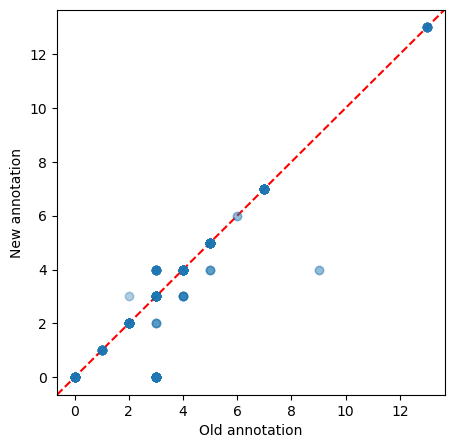

In [53]:
plt.figure(figsize=(5, 5))
plt.scatter(cn_old, cn_new, alpha=.1, zorder=3)
plt.axline((0, 0), slope=1, color='red', ls='--', zorder=0)
plt.xlabel('Old annotation')
plt.ylabel('New annotation')

The differences are probably due to stochasicity of internal steps (GAM fitting and HMM segmentation).